In [4]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

## Data Generation

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)




In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## PAFM with Postional Encoding

(128, 57)
128 train done
128 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


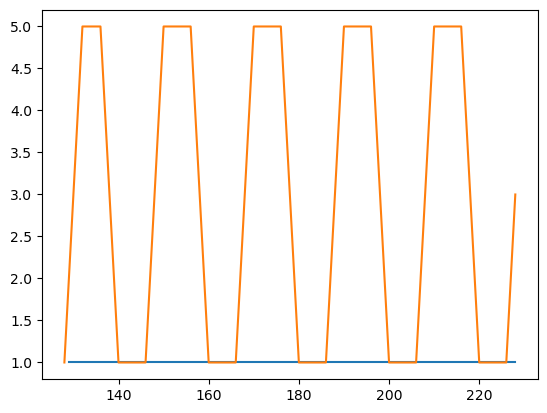

(256, 57)
256 train done
256 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1736186955686367


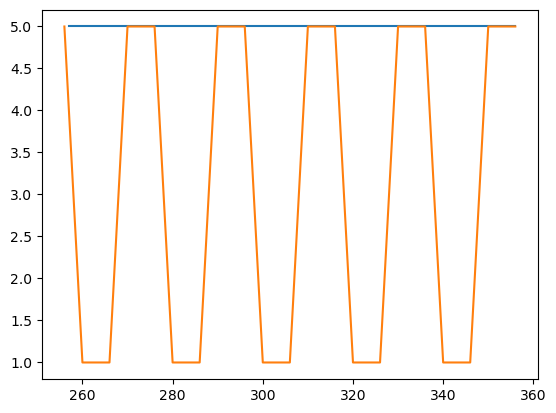

(512, 57)
512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.9445211839239144


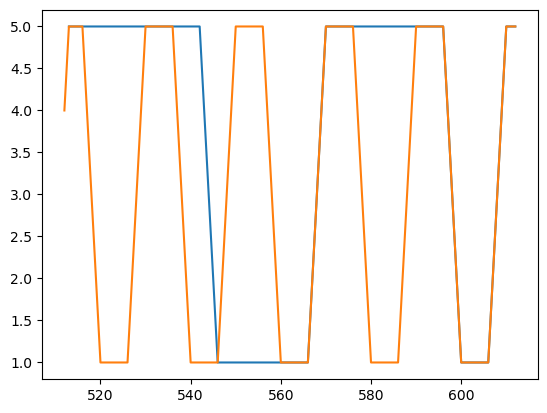

(750, 57)
750 train done
750 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.155521024068058


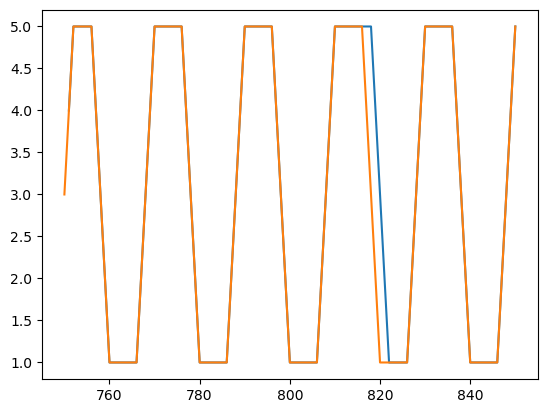

(1024, 57)
1024 train done
1024 [np.float64(2.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


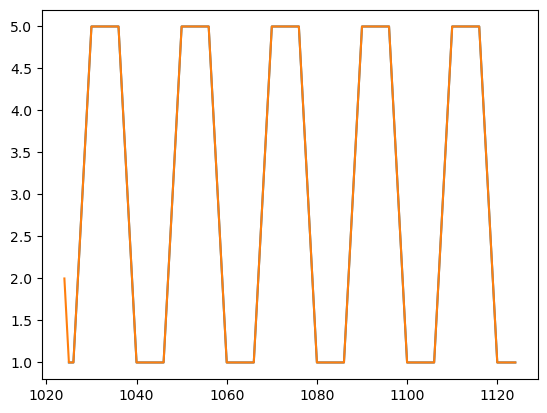

(1250, 57)
1250 train done
1250 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


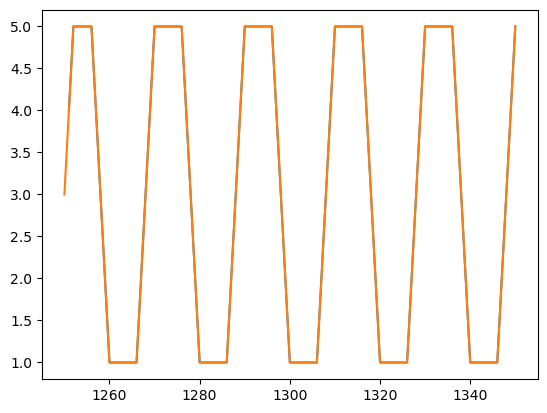

(1500, 57)
1500 train done
1500 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


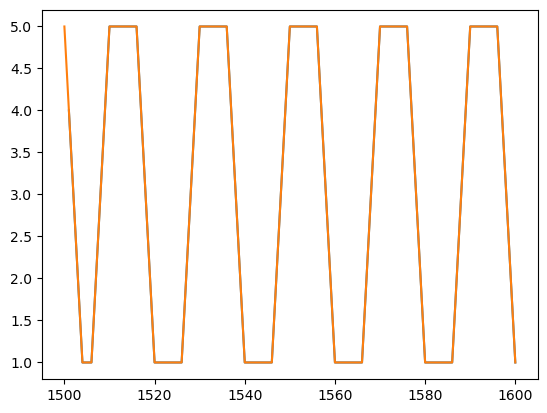

(2048, 57)
2048 train done
2048 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


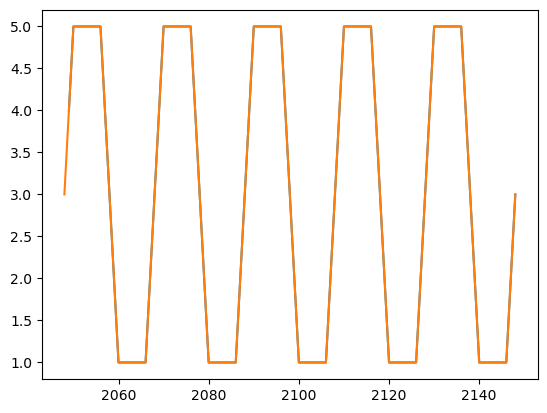

In [4]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
for t_prime in [6]:
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="pe")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]
        print(X_train.shape)
        rf = RandomForestRegressor(n_estimators=1000)
        # rf = ObliqueRandomForestRegressor(n_estimators=1000)
        rf.fit(X_train, Y_train)
        print(T,'train done')
        current_state = states[T,0]
        # print(current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="pe")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = rf.predict(features)

            # # Compute instantaneous rewards
            # for i, row in df_all_paths.iterrows():
            #     for t in np.arange(t_prime+1):
            #         cand = row[f"t={T+delta_t+t}"]
            #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
            #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
            #         irewards_pred[i, t] = rf.predict(features)[0]

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()


    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/RF_pe_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
        future_states =FUTURE_STATE_arr
        )

(128, 57) (128,)
128 train done
128 [np.float64(1.0), 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


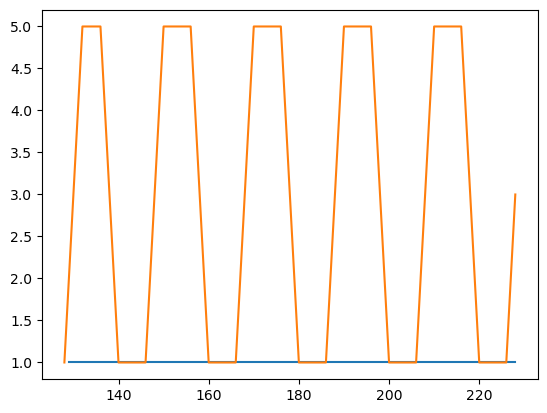

(256, 57) (256,)
256 train done
256 [np.float64(5.0), 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1736186955686367


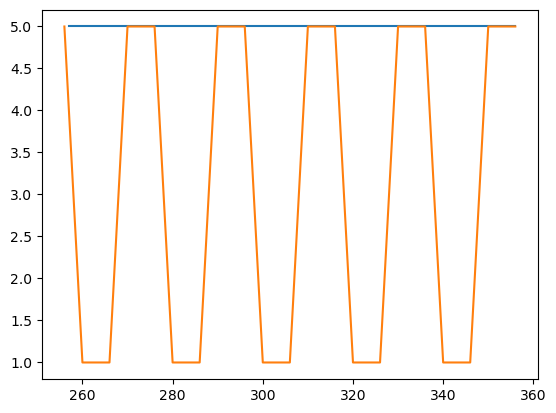

(512, 57) (512,)
512 train done
512 [np.float64(4.0), 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.8975494737676644


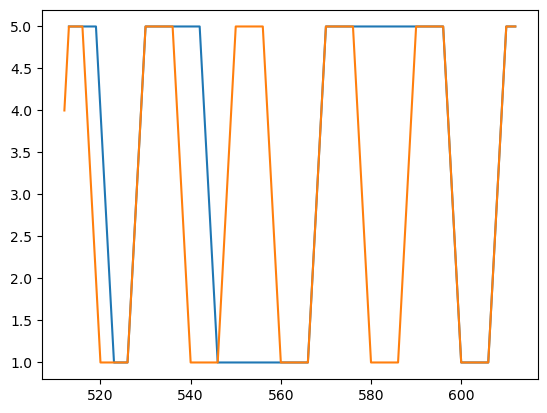

(750, 57) (750,)
750 train done
750 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.155521024068058


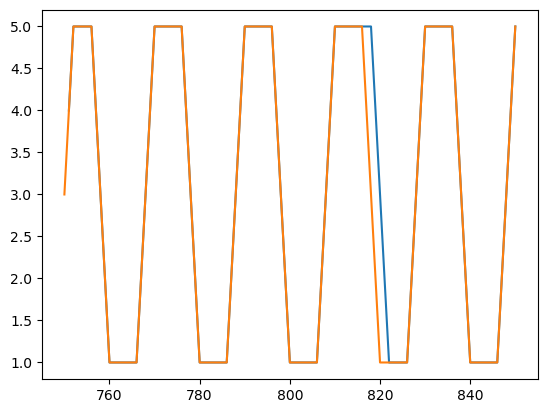

(1024, 57) (1024,)
1024 train done
1024 [np.float64(2.0), 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


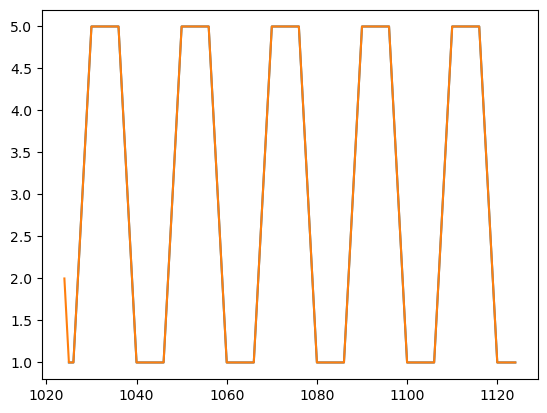

(1250, 57) (1250,)
1250 train done
1250 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


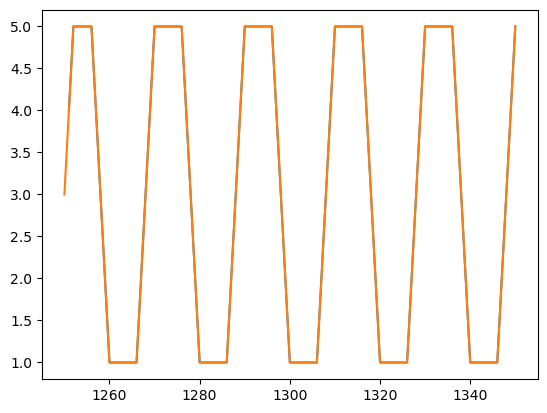

(1500, 57) (1500,)
1500 train done
1500 [np.float64(5.0), 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


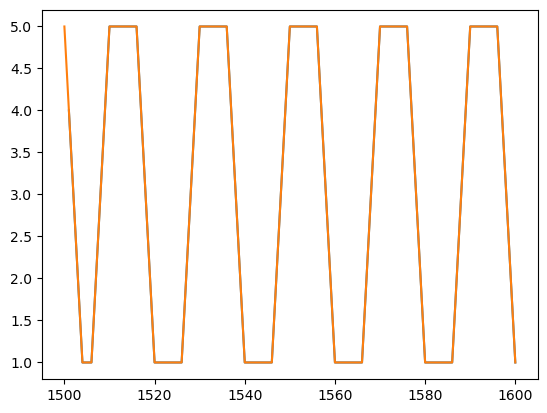

(2048, 57) (2048,)
2048 train done
2048 [np.float64(3.0), 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


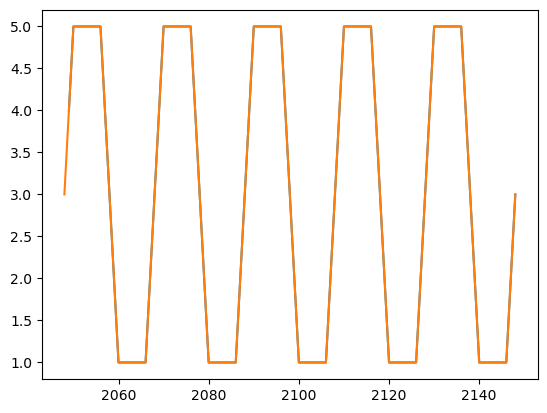

In [ ]:
# gamma = 0.5
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
for t_prime in [6]:
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]
        print(X_train.shape,Y_train.shape)
        rf = RandomForestRegressor(n_estimators=1000)
        # rf = ObliqueRandomForestRegressor(n_estimators=1000)
        rf.fit(X_train, Y_train)
        print(T,'train done')
        current_state = states[T,0]
        # print(current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                irewards_pred[:,i] = rf.predict(features)

            # # Compute instantaneous rewards
            # for i, row in df_all_paths.iterrows():
            #     for t in np.arange(t_prime+1):
            #         cand = row[f"t={T+delta_t+t}"]
            #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
            #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
            #         irewards_pred[i, t] = rf.predict(features)[0]

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/RF_oh_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
        future_states =FUTURE_STATE_arr
        )


## PAFM optimal

21
(126, 57) (126,)
128 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73300/4060653570.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1920663964209344


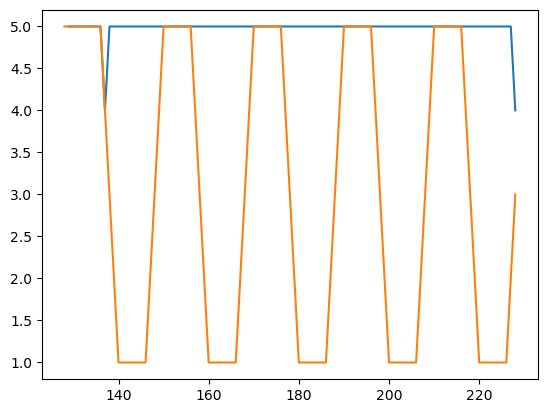

42
(252, 57) (252,)
256 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73300/4060653570.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


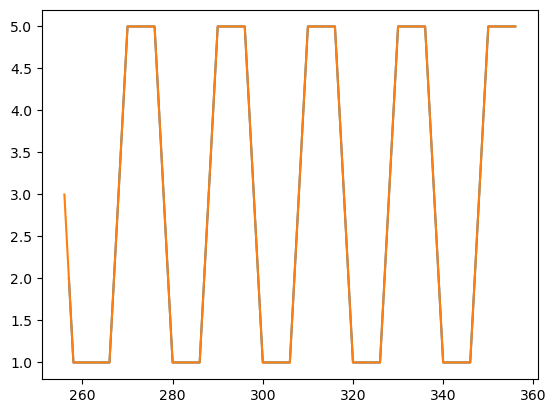

85
(510, 57) (510,)
512 train done
0.0


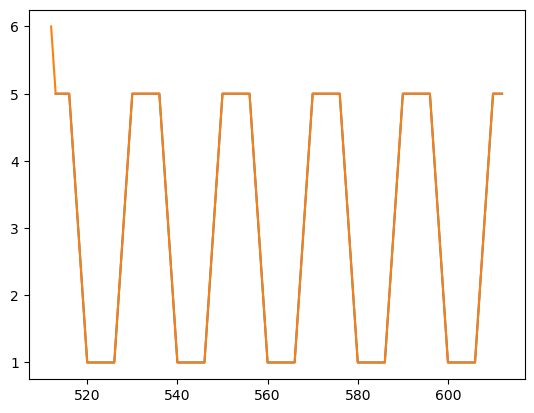

125
(750, 57) (750,)
750 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73300/4060653570.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.03934979999999996


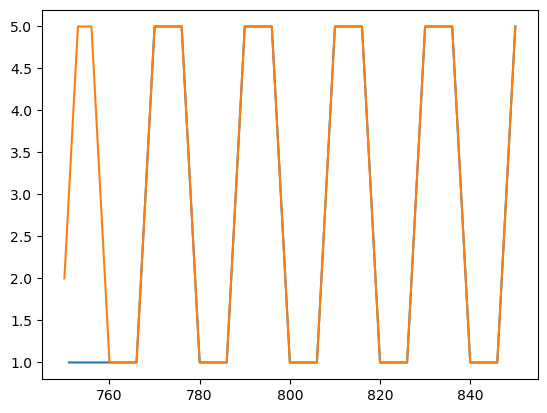

170
(1020, 57) (1020,)
1024 train done
0.0


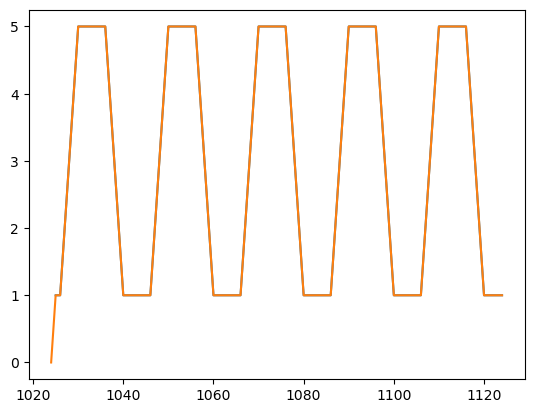

208
(1248, 57) (1248,)
1250 train done
0.011809800000000053


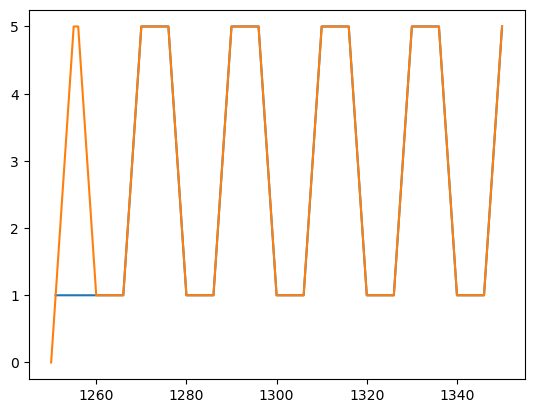

250
(1500, 57) (1500,)
1500 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73300/4060653570.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


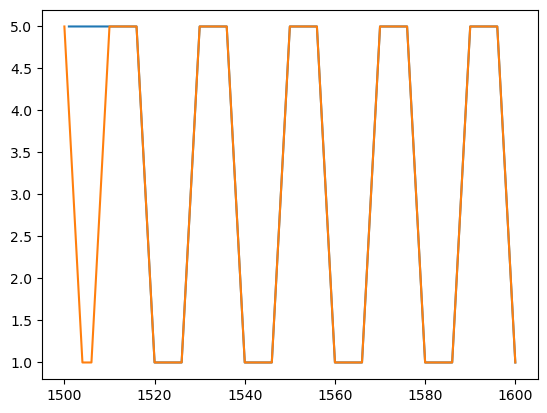

341
(2046, 57) (2046,)
2048 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73300/4060653570.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


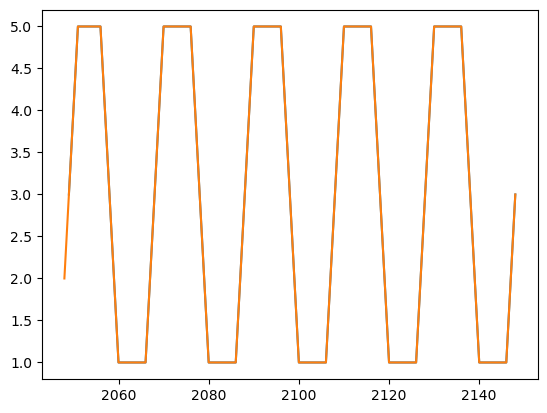

In [45]:
DELTA_t = 5
t_prime = 6
# Ts = [2**i for i in np.arange(7,8)]+[150,175,200,225]+[2**i for i in np.arange(8,10)]+[750]+[1024,1250,1500,2048]
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
for T in Ts:
    n_seq = int(T/(DELTA_t+1))
    # n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards,gamma = 0.5))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe)
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
    X_train = STATES_arr
    Y_train = REWARDS_arr
    rf = RandomForestRegressor(n_estimators=1000, random_state=9515)
    ## Using XGB regressor with delta = 1 is converging faster -- 150
    # rf = xgb.XGBRegressor(
    #     objective="reg:squarederror",
    #     tree_method="exact",     # or "exact" (slower, RAM heavy)
    #     n_jobs = -1,
    #     learning_rate=0.05, max_depth=5,
    #     subsample=1, colsample_bytree=0.8,
    #     n_estimators=1000, eval_metric="rmse"
    # )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = rf.predict(features)
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
    
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PAFM/RF_optimal_oh_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )

